<a href="https://colab.research.google.com/github/alvarezaguayomiguel1472-commits/Aprendizaje-Automatico/blob/main/Modelo_de_Clasificaci%C3%B3n_de_C%C3%A1ncer_de_Mama_-_%C3%81lvarez_Aguayo_Miguel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Clasificación de Cáncer de Mama
## Descripción:
- Dataset: load_breast_cancer de sklearn
- Objetivo: Clasificar los tumores como benignos o malignos.
- Modelo: Regresión Logística (se requiere clasificación binaria)

## Autor: Álvarez Aguayo Miguel Alejandro
## Fecha: 13/06/2026

## Importación de Dataset y Librerias.

In [81]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV,StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score, roc_curve, roc_auc_score, RocCurveDisplay, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.svm import SVC
from scipy.stats import loguniform, randint

## Carga del Dataset

In [82]:
df_breast_cancer = load_breast_cancer()
X = pd.DataFrame(data=df_breast_cancer.data, columns=df_breast_cancer.feature_names)
y = df_breast_cancer.target
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## EDA Temporal

In [83]:
print(pd.Series(y).value_counts())
print(pd.Series(y).value_counts(normalize = True))

1    357
0    212
Name: count, dtype: int64
1    0.627417
0    0.372583
Name: proportion, dtype: float64


## Entrenamiento del modelo

In [84]:
X_divisible, X_test, y_divisible, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=2004)
X_train, X_val, y_train, y_val = train_test_split(X_divisible, y_divisible, test_size=0.30, random_state=2004, stratify=y_divisible)
modelo = LogisticRegression(max_iter = 5000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [85]:
y_pred = modelo.predict(X_test)

## Matriz de Confusión

<function matplotlib.pyplot.show(close=None, block=None)>

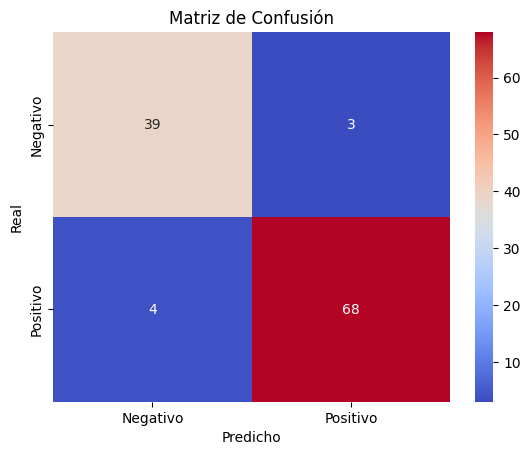

In [86]:
matriz_confusion = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz_confusion,
            annot=True,
            fmt='d',
            cmap = 'coolwarm',
            xticklabels = ['Negativo', 'Positivo'],
            yticklabels = ['Negativo', 'Positivo'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show

## Cálculo de Métricas

In [87]:
# Calcula Precisión, Recall, F1-Score
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)


print(f"F1 Score: {f1}")
print(f"Recall Score: {recall}")
print(f"Precision Score: {precision}")


F1 Score: 0.951048951048951
Recall Score: 0.9444444444444444
Precision Score: 0.9577464788732394


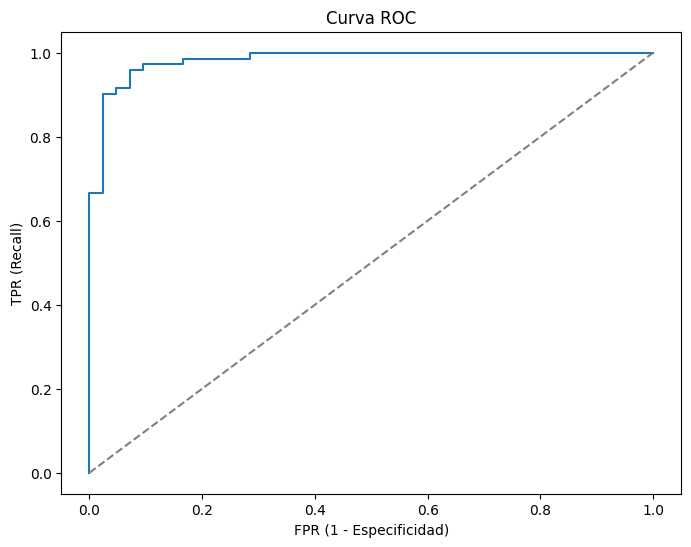

In [88]:
y_proba = modelo.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_proba)

# Gráfica de la curva roc
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray', label='Aleatorio')
plt.xlabel('FPR (1 - Especificidad)')
plt.ylabel('TPR (Recall)')
plt.title('Curva ROC')
plt.show()

## Validación Cruzada con KFold

In [89]:
# k = 10
kf = KFold(n_splits=10,
shuffle=True,
random_state=2004)
scores = cross_val_score(
SVC(), X, y,
cv=kf,
scoring='f1_weighted')
print(f"F1 medio: {scores.mean():.4f} ± {scores.std():.4f}")

F1 medio: 0.9189 ± 0.0254


In [90]:
# k = 5
kf_5 = KFold(n_splits=5,
shuffle=True,
random_state=2004)
scores = cross_val_score(
SVC(), X, y,
cv=kf_5,
scoring='f1_weighted')
print(f"F1 medio: {scores.mean():.4f}"
f" ± {scores.std():.4f}")

F1 medio: 0.9136 ± 0.0219


In [91]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' soporta l1 y l2
}

# GridSearchCV
grid_search = GridSearchCV(LogisticRegression(max_iter=10000, random_state=2004), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# RandomSearchCV
random_search = RandomizedSearchCV(LogisticRegression(max_iter=10000, random_state=2004), param_distributions=param_grid, n_iter=8, cv=5, scoring='f1', random_state=2004)
random_search.fit(X_train, y_train)

print("\n======== Optimización de Hiperparámetros ========")
print(f"GridSearchCV mejor F1: {grid_search.best_score_:.4f} usando {grid_search.best_params_}")
print(f"RandomSearchCV mejor F1: {random_search.best_score_:.4f} usando {random_search.best_params_}")


======== Optimización de Hiperparámetros ========
GridSearchCV mejor F1: 0.9671 usando {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
RandomSearchCV mejor F1: 0.9671 usando {'solver': 'liblinear', 'penalty': 'l1', 'C': 100}


In [92]:
y_prob = modelo.predict_proba(X_val)[:,1]
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
for thresh in thresholds:
  y_pred_t = (y_prob >= thresh).astype(int)
  f1_scores.append(
    f1_score(y_val, y_pred_t))
# Umbral óptimo para F1
best_thresh = thresholds[
np.argmax(f1_scores)]
print(f"Umbral óptimo: {best_thresh:.2f}")
print(f"F1 máximo: {max(f1_scores):.4f}")
# Aplicar umbral óptimo al test
y_final = (y_proba>= best_thresh).astype(int)

Umbral óptimo: 0.53
F1 máximo: 0.9591


=== Comparación de Umbrales ===
Métrica         Umbral 0.5      Umbral 0.53     Cambio    
-------------------------------------------------------
Precision       0.9577          0.9571          -0.0006
Recall          0.9444          0.9306          -0.0139
F1-Score        0.9510          0.9437          -0.0074



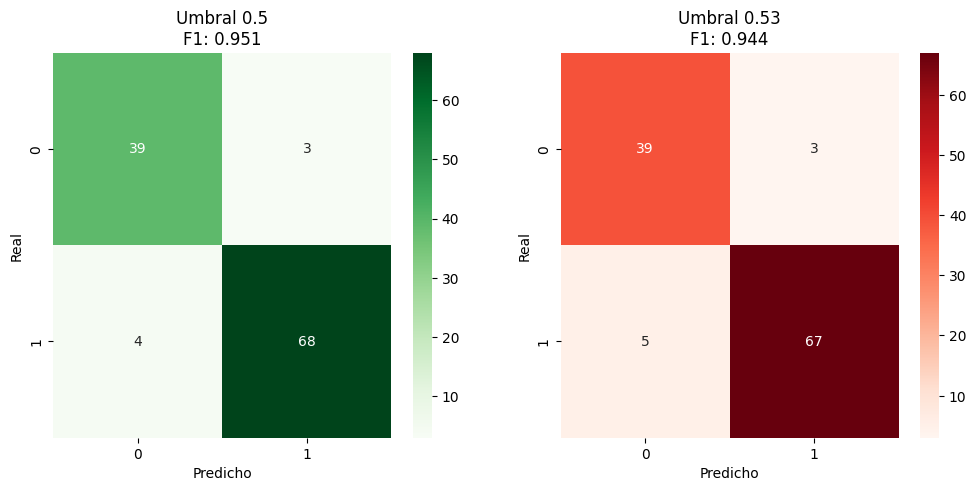

In [99]:
y_proba_test = modelo.predict_proba(X_test)[:,1]
# Umbral por defecto en 0.5
y_pred_default = (y_proba_test >= 0.5).astype(int)

# Umbral óptimo (0.82)
y_pred_optimo = (y_proba_test >= 0.53).astype(int)

# Representación en forma de tabla
print("=== Comparación de Umbrales ===")
print(f"{'Métrica':<15} {'Umbral 0.5':<15} {'Umbral 0.53':<15} {'Cambio':<10}")
print("-" * 55)

#Precision
prec_default = precision_score(y_test, y_pred_default)
prec_optimo = precision_score(y_test, y_pred_optimo)
print(f"{'Precision':<15} {prec_default:<15.4f} {prec_optimo:<15.4f} {prec_optimo-prec_default:+.4f}")

# Recall
rec_default = recall_score(y_test, y_pred_default)
rec_optimo = recall_score(y_test, y_pred_optimo)
print(f"{'Recall':<15} {rec_default:<15.4f} {rec_optimo:<15.4f} {rec_optimo-rec_default:+.4f}")
# F1
f1_default= f1_score(y_test, y_pred_default)
f1_optimo = f1_score(y_test, y_pred_optimo)
print(f"{'F1-Score':<15} {f1_default:<15.4f} {f1_optimo:<15.4f} {f1_optimo-f1_default:+.4f}\n")

# Grafico Heatmap de la matriz de consfusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title(f'Umbral 0.5\nF1: {f1_default:.3f}')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Matriz con umbral 0.82
cm_optimo = confusion_matrix(y_test, y_pred_optimo)
sns.heatmap(cm_optimo, annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title(f'Umbral 0.53\nF1: {f1_optimo:.3f}')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.show()

Como conclusión tenemos que el umbral de 0.53 mediante la metrica F1 score con los datos de validacion tiene mejor rendimiento pero cuando evaluamos con respecto a los datos de prueba vemos que un valor mas cercano al umbral por defecto (0.5).
Entonces en terminos practicos podemos determinar que el umbral de 0.5 es la mejor opción para el modelo final.
-